# Import

In [12]:
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pysam
import re
import pandas as pd
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({'font.size': 20})
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.ticker as ticker
import matplotlib

# Function

In [9]:
def plot(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)
    y2_values = [float(val[1]) for val in loc1.values()]  # Second part of the stack (converted to int)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue',align='center',width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_methylation.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [3]:
def plotDepthIntron(loc1,inFile,file, title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [4]:
def Intron6t8meth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage of CpG Methylation in Intron 6 to 8", out)

In [5]:
def plotDepthTAPAS(loc1,inFile,file,title):
    depth_file = "/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile  # Replace with your samtools depth output file
    positions, depths = [], []

    with open(depth_file) as f:
        for line in f:
            chrom, pos, depth = line.strip().split("\t")
            positions.append(int(pos))
            depths.append(int(depth))

    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')


    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))
    # Create the stacked bar plot
    plt.bar(x, depths, color='brown',width=1.0, alpha=1)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel("Positions", fontsize=12)
    plt.ylabel("Coverage", fontsize=12)
    plt.title(title, fontsize=12)
    #plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    print(file)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+title+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [6]:
 def TAPASmeth(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", out)

In [7]:
 def TAPASmethZoom(inFile,out):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plotZoom(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", out)

In [8]:
def plotCov(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(10,4)
    plt.rcParams.update({'font.size': 12})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='coverage', color='brown',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+"_coverage.pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [9]:
def plotZoom(loc1, Xlabel, Ylabel, title, out):
    import matplotlib.pyplot as plt
    import matplotlib
    import numpy as np
    import matplotlib.patheffects as mpe

    fig = plt.gcf()
    fig.set_size_inches(13, 4)
    plt.rcParams.update({'font.size': 12})
    outline = mpe.withStroke(linewidth=8, foreground='black')

    # Define range to include only positions between 1201123 and 1204643
    start_pos = 1201123
    end_pos = 1204643

    # Filter loc1 based on key range (keys must be numeric)
    filtered_loc1 = {
        k: v for k, v in loc1.items()
        if start_pos <= float(k) <= end_pos
    }

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(filtered_loc1.keys())
    y1_values = [float(val[0]) for val in filtered_loc1.values()]
    y2_values = [float(val[1]) for val in filtered_loc1.values()]

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue', align='center', width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red', align='center', width=5)

    # Customize the plot
    tick_positions = np.linspace(0, len(x_labels) - 1, num=min(10, len(x_labels)), dtype=int)
    tick_labels = [f"{int(float(x_labels[i])):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=12)
    plt.xlabel(Xlabel, fontsize=12)
    plt.ylabel(Ylabel, fontsize=12)
    plt.title(title, fontsize=12)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)

    # Add a border around the plot
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    # Font type for vector export
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42

    # Save and show
    plt.tight_layout()
    plt.savefig(
        f"/media/data_01/vapatter/PROJECTS/15-LARS/PDF/{out}_methylation.pdf",
        format="pdf",
        bbox_inches="tight"
    )
    plt.show()


In [8]:
import pysam

# Input files
bam_input = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/HEK_72h_hTAPAS_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam"
readnames_file = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/plasmidReads.txt"
bam_output_unsorted = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.unsorted.bam"
bam_output_sorted = "/media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.sorted.bam"

# Load read names to remove into a set for fast lookup
with open(readnames_file) as f:
    remove_readnames = set(line.strip() for line in f if line.strip())

# Open input BAM
with pysam.AlignmentFile(bam_input, "rb") as bam_in:
    # Create unsorted output BAM
    with pysam.AlignmentFile(bam_output_unsorted, "wb", header=bam_in.header) as bam_out:
        for read in bam_in.fetch(until_eof=True):
            if read.query_name not in remove_readnames:
                bam_out.write(read)

# Sort the BAM file
pysam.sort("-o", bam_output_sorted, bam_output_unsorted)

# Index the sorted BAM (optional but recommended)
pysam.index(bam_output_sorted)

# Clean up if desired
import os
os.remove(bam_output_unsorted)

print(f"Filtered and sorted BAM saved to: {bam_output_sorted}")

Filtered and sorted BAM saved to: /media/data_01/vapatter/PROJECTS/15-LARS/149_LE_hTERT_HEK72h/T2T/output.filtered.sorted.bam


# Intron 6 to 8

## Coverage

In [10]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 1.87486
Standard deviation: 0.331971
2
2


In [11]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T
for f in *sorted.bam; 
do samtools depth -a -b /media/data_01/vapatter/PROJECTS/15-LARS/125_NDLE_hTERT_CRISPR_VA13/T2T/locations.bed \
$f > $f.Intron_coverage.txt; done

ls *.Intron_coverage.txt > coveragesINTRON.txt

176_176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.Intron_coverage.txt


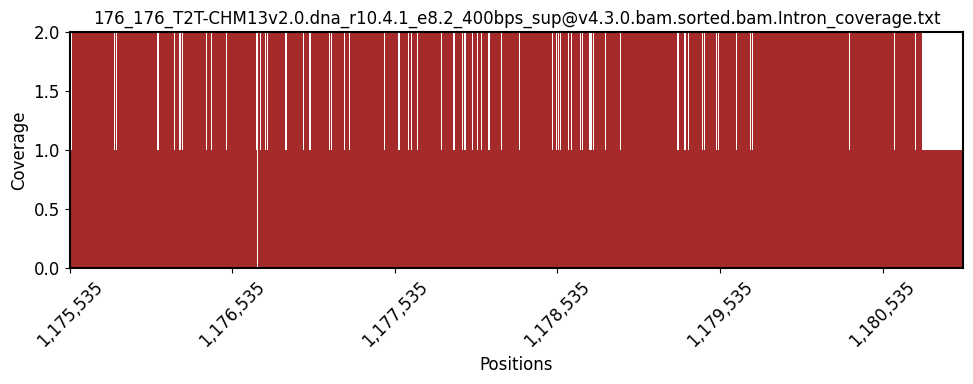

In [13]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

seqLoc2 = {}

count = 1175534

for line in file:
    
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/coveragesINTRON.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthIntron(seqLoc2,"176_hTERT_target_demeth/T2T/"+f,"176_"+f,"176_"+f)

## Methylation

176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


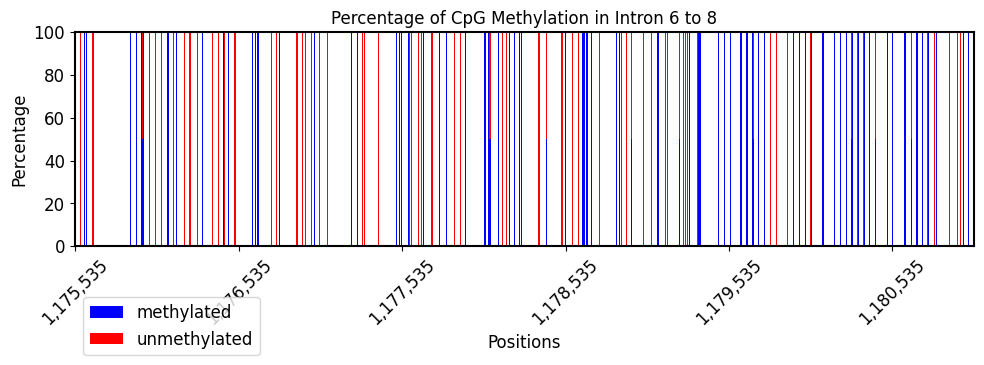

In [14]:
Intron6t8meth("176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
             "176_hTERT_target_demeth_intron")

## Annotation

# TAPAS

## Coverage

In [15]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 1.37967
Standard deviation: 0.491498
7
7


In [17]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/
for f in *.sorted.bam; 
do samtools depth -a -b /media/data_01/vapatter/PROJECTS/15-LARS/125_NDLE_hTERT_CRISPR_VA13/T2T/locations2.bed \
$f > $f.hTAPAS_coverage.txt; done
ls *$f.hTAPAS_coverage.txt > coveragesTAPAS.txt

176_176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.hTAPAS_coverage.txt


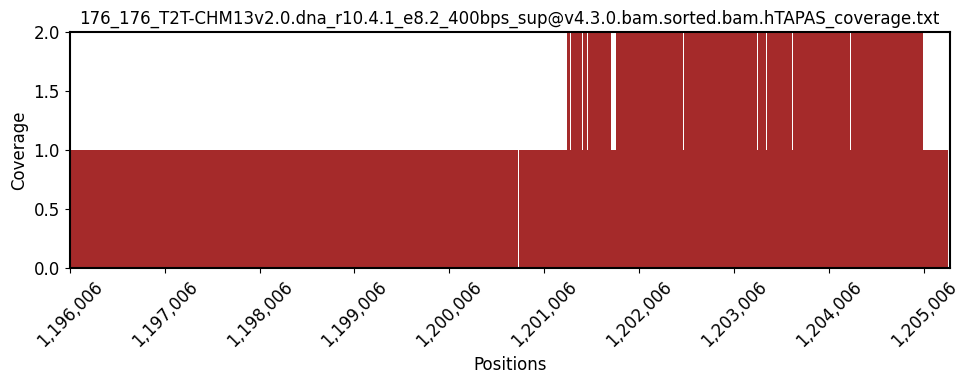

In [18]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

seqLoc2 = {}

count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count +=1
        seqLoc2[count]=[count]
file.close()
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/coveragesTAPAS.txt", header = None)
files = list(files[0])
for f in files:
    plotDepthTAPAS(seqLoc2,"176_hTERT_target_demeth/T2T/"+f,"176_"+f,"176_"+f)

## Methylation

176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


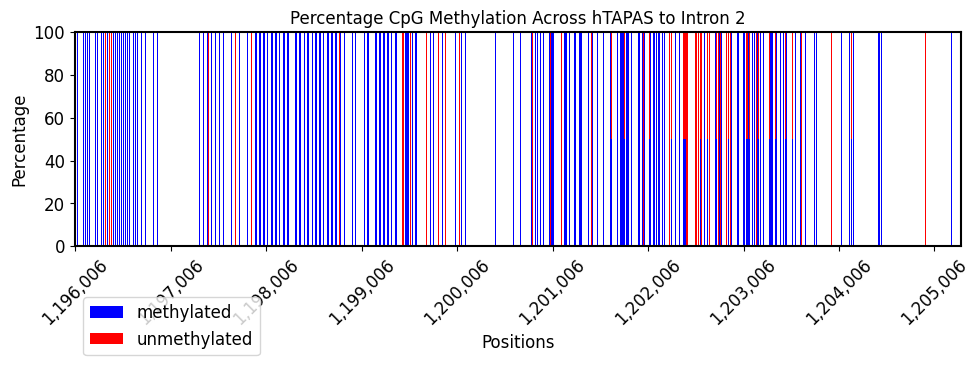

In [20]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("176_hTERT_target_demeth/T2T/"+f,"176_"+f+"_hTAPAS")

## Annotation

/tmp/ipykernel_1609279/829942186.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


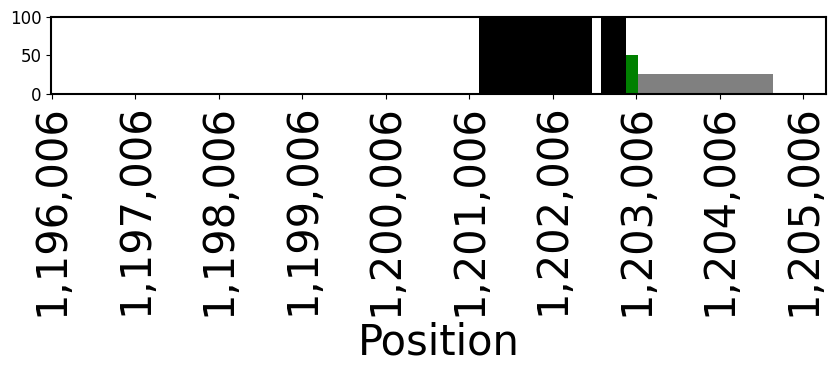

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

# Initialize annot dictionary
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa", "r")
annot = {}
count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count += 1
        annot[count] = 0
file.close()

# Define regions to color-code
for k, v in annot.items():
    if 1201123 <= k <= 1202476:
        annot[k] = 100
    elif 1202581 <= k <= 1202878:
        annot[k] = 100
    elif 1202862 <= k <= 1203024:
        annot[k] = 50
    elif 1203024 <= k <= 1204643:
        annot[k] = 25

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(10, 1)
plt.rcParams.update({'font.size': 12})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
#black_patch = mpatches.Patch(color='black', label='exon')
#green_patch = mpatches.Patch(color='green', label='core promoter')
#grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

#plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPASAnnotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()


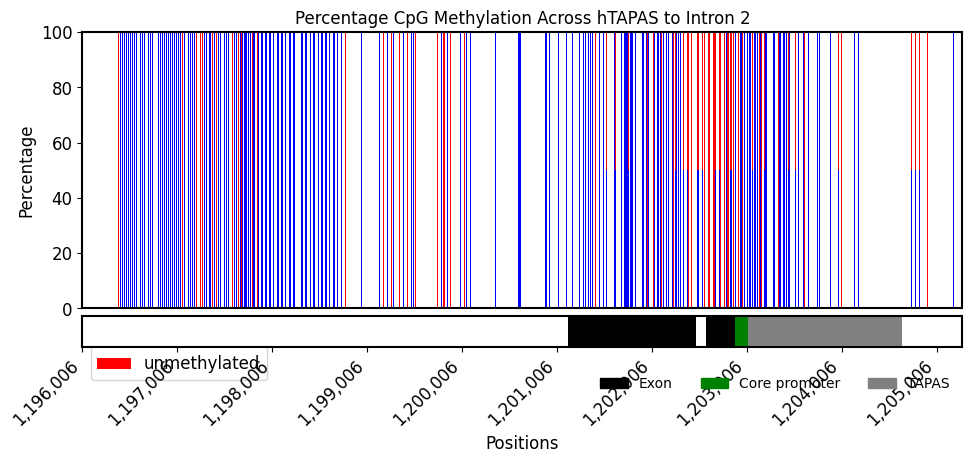

Input: /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed
Methylation sites plotted: 573
Output: /media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPAS_methylation_and_annotation.pdf


In [14]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


GENOME_START = 1_196_006
GENOME_END = 1_205_278
CHROMOSOME = "NC_060929.1"

LOC2_FASTA = Path(
    "/media/data_01/shared/GENOMES/homo_sapiens/"
    "T2T-CHM13v2.0/genome/loc2.fa"
)

PROJECT_DIR = Path(
    "/media/data_01/vapatter/PROJECTS/15-LARS"
)


def TAPASmeth(in_file, out_file):
    """
    Plot CpG methylation in the original stacked-bar style,
    with the hTAPAS annotation track underneath.

    Parameters
    ----------
    in_file : str
        Input tab-delimited methylation filename inside PROJECT_DIR.

    out_file : str
        Output filename, such as:
        "PDF/sample_hTAPAS.pdf"
    """

    plt.rcParams.update({"font.size": 12})

    matplotlib.rcParams["pdf.fonttype"] = 42
    matplotlib.rcParams["ps.fonttype"] = 42

    # ============================================================
    # Create genomic coordinate array from FASTA sequence length
    # ============================================================

    sequence_length = 0

    with LOC2_FASTA.open("r") as fasta:
        for line in fasta:
            line = line.strip()

            if not line or line.startswith(">"):
                continue

            sequence_length += len(line)

    positions = np.arange(
        GENOME_START,
        GENOME_START + sequence_length
    )

    interval_mask = (
        (positions >= GENOME_START)
        & (positions <= GENOME_END)
    )

    positions = positions[interval_mask]

    if len(positions) == 0:
        raise ValueError(
            "No positions were found within the requested interval."
        )

    # Original plot uses [methylated, unmethylated].
    # Positions without measurements remain [0, 0].
    methylated = np.zeros(
        len(positions),
        dtype=float
    )

    unmethylated = np.zeros(
        len(positions),
        dtype=float
    )

    position_to_index = {
        int(position): index
        for index, position in enumerate(positions)
    }

    # ============================================================
    # Read methylation data
    # ============================================================

    input_path = PROJECT_DIR / in_file

    with input_path.open("r") as methylation_file:
        for line_number, line in enumerate(
            methylation_file,
            start=1
        ):
            columns = line.rstrip("\n").split("\t")

            if len(columns) <= 10:
                continue

            if columns[0] != CHROMOSOME:
                continue

            if columns[3] != "m":
                continue

            try:
                genomic_position = int(columns[1])
                methylation_value = float(columns[10])
            except ValueError:
                # Skip headers and malformed lines
                continue

            index = position_to_index.get(genomic_position)

            if index is None:
                continue

            methylated[index] = methylation_value
            unmethylated[index] = 100 - methylation_value

    # ============================================================
    # Build annotation track
    # ============================================================

    annotation_codes = np.zeros(
        len(positions),
        dtype=int
    )

    # TAPAS
    annotation_codes[
        (positions >= 1_203_024)
        & (positions <= 1_204_643)
    ] = 25

    # Core promoter
    annotation_codes[
        (positions >= 1_202_862)
        & (positions <= 1_203_024)
    ] = 50

    # Exon
    annotation_codes[
        (positions >= 1_201_123)
        & (positions <= 1_202_476)
    ] = 100

    # Exon
    annotation_codes[
        (positions >= 1_202_581)
        & (positions <= 1_202_878)
    ] = 100

    annotation_colors = [
        "black" if code == 100
        else "green" if code == 50
        else "grey" if code == 25
        else "white"
        for code in annotation_codes
    ]

    # ============================================================
    # Use positional x coordinates, matching the original plot
    # ============================================================

    x_labels = positions.tolist()
    x = np.arange(len(x_labels))

    # ============================================================
    # Create combined figure
    # ============================================================

    fig, (
        methylation_ax,
        annotation_ax
    ) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10, 5),
        sharex=True,
        gridspec_kw={
            "height_ratios": [4, 0.45],
            "hspace": 0.05
        }
    )

    # ============================================================
    # Original-style methylation plot
    # ============================================================

    methylation_ax.bar(
        x,
        methylated,
        label="methylated",
        color="blue",
        align="center",
        width=5
    )

    methylation_ax.bar(
        x,
        unmethylated,
        bottom=methylated,
        label="unmethylated",
        color="red",
        align="center",
        width=5
    )

    methylation_ax.set_ylim(0, 100)

    methylation_ax.set_ylabel(
        "Percentage",
        fontsize=12
    )

    methylation_ax.set_title(
        "Percentage CpG Methylation Across "
        "hTAPAS to Intron 2",
        fontsize=12
    )

    methylation_ax.legend(
        bbox_to_anchor=(0, -0.02),
        loc="upper left",
        frameon=True
    )

    methylation_ax.margins(0)

    # Do not show genomic labels on the upper panel
    methylation_ax.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False
    )

    # ============================================================
    # Annotation track underneath
    # ============================================================

    annotation_ax.bar(
        x,
        np.ones(len(x)),
        color=annotation_colors,
        align="center",
        width=5,
        edgecolor="none"
    )

    annotation_ax.set_ylim(0, 1)
    annotation_ax.set_yticks([])
    annotation_ax.margins(0)

    # ============================================================
    # X-axis formatting matching original plot
    # ============================================================

    tick_positions = np.arange(
        0,
        len(x_labels),
        1000
    )

    tick_labels = [
        f"{int(x_labels[index]):,}"
        for index in tick_positions
    ]

    annotation_ax.set_xticks(
        tick_positions
    )

    annotation_ax.set_xticklabels(
        tick_labels,
        rotation=45,
        fontsize=12,
        ha="right"
    )

    annotation_ax.set_xlabel(
        "Positions",
        fontsize=12
    )

    # Exact alignment between both panels
    methylation_ax.set_xlim(
        -0.5,
        len(x) - 0.5
    )

    annotation_ax.set_xlim(
        -0.5,
        len(x) - 0.5
    )

    # ============================================================
    # Annotation legend
    # ============================================================

    annotation_legend = [
        mpatches.Patch(
            color="black",
            label="Exon"
        ),
        mpatches.Patch(
            color="green",
            label="Core promoter"
        ),
        mpatches.Patch(
            color="grey",
            label="TAPAS"
        )
    ]

    annotation_ax.legend(
        handles=annotation_legend,
        bbox_to_anchor=(1, -0.55),
        loc="upper right",
        ncol=3,
        frameon=False,
        fontsize=10
    )

    # ============================================================
    # Borders matching original style
    # ============================================================

    for axis in (
        methylation_ax,
        annotation_ax
    ):
        axis.spines["top"].set_linewidth(1.5)
        axis.spines["right"].set_linewidth(1.5)
        axis.spines["bottom"].set_linewidth(1.5)
        axis.spines["left"].set_linewidth(1.5)

    # ============================================================
    # Save output
    # ============================================================

    output_path = PROJECT_DIR / out_file

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    output_format = (
        output_path.suffix.lstrip(".")
        or "pdf"
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.90,
        bottom=0.27
    )

    fig.savefig(
        output_path,
        format=output_format,
        bbox_inches="tight",
        dpi=300
    )

    plt.show()
    plt.close(fig)

    measured_count = int(
        np.count_nonzero(
            (methylated != 0)
            | (unmethylated != 0)
        )
    )

    print(f"Input: {input_path}")
    print(f"Methylation sites plotted: {measured_count}")
    print(f"Output: {output_path}")


# ================================================================
# Example
# ================================================================

TAPASmeth(
    "176_hTERT_target_demeth/T2T/"
    "176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_"
    "sup@v4.3.0.bam.sorted.bam.bed",
    "PDF/hTAPAS_methylation_and_annotation.pdf"
)

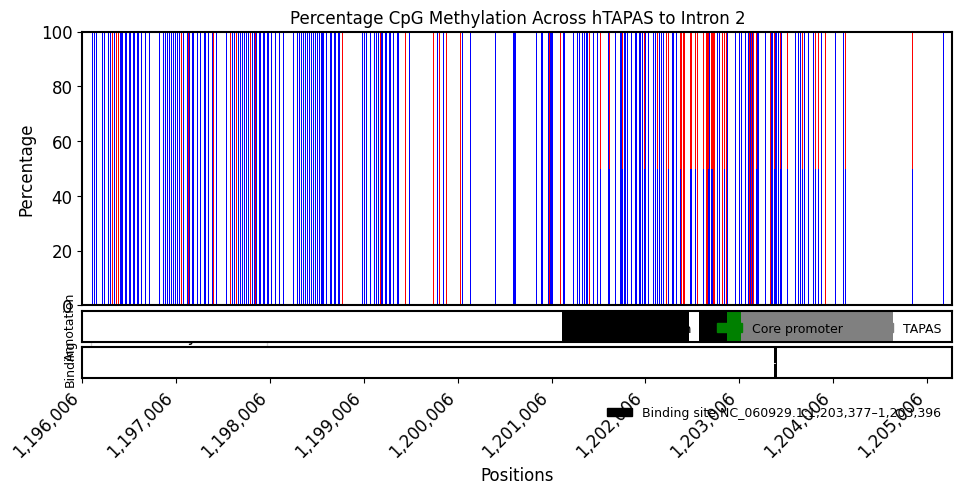

Input: /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed
Methylation sites plotted: 573
Binding site plotted: NC_060929.1:1,203,377-1,203,396
Output: /media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPAS_methylation_annotation_binding.pdf


In [18]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


GENOME_START = 1_196_006
GENOME_END = 1_205_278
CHROMOSOME = "NC_060929.1"

# Fixed binding-site coordinates, inclusive
BINDING_START = 1_203_377
BINDING_END = 1_203_396

LOC2_FASTA = Path(
    "/media/data_01/shared/GENOMES/homo_sapiens/"
    "T2T-CHM13v2.0/genome/loc2.fa"
)

PROJECT_DIR = Path(
    "/media/data_01/vapatter/PROJECTS/15-LARS"
)


def TAPASmeth(in_file, out_file):
    """
    Plot methylation, genomic annotations and a fixed binding site.

    Parameters
    ----------
    in_file : str
        Methylation file relative to PROJECT_DIR.

    out_file : str
        Output PDF filename relative to PROJECT_DIR.
    """

    plt.rcParams.update({"font.size": 12})

    matplotlib.rcParams["pdf.fonttype"] = 42
    matplotlib.rcParams["ps.fonttype"] = 42

    # ============================================================
    # Read FASTA sequence
    # ============================================================

    fasta_parts = []

    with LOC2_FASTA.open("r") as fasta:
        for line in fasta:
            line = line.strip()

            # Ignore FASTA headers and blank lines
            if not line or line.startswith(">"):
                continue

            fasta_parts.append(line.upper())

    complete_sequence = "".join(fasta_parts)

    if not complete_sequence:
        raise ValueError(
            f"No sequence was found in {LOC2_FASTA}"
        )

    # The first FASTA base is assumed to correspond to GENOME_START.
    complete_positions = np.arange(
        GENOME_START,
        GENOME_START + len(complete_sequence)
    )

    # Restrict coordinates to the plotted interval.
    interval_mask = (
        (complete_positions >= GENOME_START)
        & (complete_positions <= GENOME_END)
    )

    positions = complete_positions[interval_mask]

    if len(positions) == 0:
        raise ValueError(
            "The requested genomic interval is outside "
            "the FASTA sequence."
        )

    # ============================================================
    # Validate the fixed binding-site coordinates
    # ============================================================

    if BINDING_START > BINDING_END:
        raise ValueError(
            "BINDING_START must not be greater than BINDING_END."
        )

    if (
        BINDING_START < int(positions[0])
        or BINDING_END > int(positions[-1])
    ):
        raise ValueError(
            "The binding site is outside the plotted interval: "
            f"{int(positions[0]):,}-{int(positions[-1]):,}"
        )

    # ============================================================
    # Prepare methylation arrays
    # ============================================================

    methylated = np.zeros(
        len(positions),
        dtype=float
    )

    unmethylated = np.zeros(
        len(positions),
        dtype=float
    )

    position_to_index = {
        int(position): index
        for index, position in enumerate(positions)
    }

    # ============================================================
    # Read methylation data
    # ============================================================

    input_path = PROJECT_DIR / in_file

    with input_path.open("r") as methylation_file:
        for line in methylation_file:
            columns = line.rstrip("\n").split("\t")

            # This script uses columns 0, 1, 3 and 10.
            if len(columns) <= 10:
                continue

            if columns[0] != CHROMOSOME:
                continue

            if columns[3] != "m":
                continue

            try:
                genomic_position = int(columns[1])
                methylation_value = float(columns[10])
            except ValueError:
                # Skip headers and malformed rows.
                continue

            index = position_to_index.get(
                genomic_position
            )

            if index is None:
                continue

            methylated[index] = methylation_value
            unmethylated[index] = 100 - methylation_value

    # ============================================================
    # Build annotation track
    # ============================================================

    annotation_codes = np.zeros(
        len(positions),
        dtype=int
    )

    # Apply the wider annotation first so narrower features can
    # overwrite it in overlapping regions.

    # TAPAS
    annotation_codes[
        (positions >= 1_203_024)
        & (positions <= 1_204_643)
    ] = 25

    # Core promoter
    annotation_codes[
        (positions >= 1_202_862)
        & (positions <= 1_203_024)
    ] = 50

    # Exon 1
    annotation_codes[
        (positions >= 1_201_123)
        & (positions <= 1_202_476)
    ] = 100

    # Exon 2
    annotation_codes[
        (positions >= 1_202_581)
        & (positions <= 1_202_878)
    ] = 100

    annotation_colors = [
        "black" if code == 100
        else "green" if code == 50
        else "grey" if code == 25
        else "white"
        for code in annotation_codes
    ]

    # ============================================================
    # Positional x-axis
    # ============================================================

    # Every x-axis unit represents one genomic base.
    x = np.arange(len(positions))

    # Convert genomic binding coordinates to the positional x-axis.
    binding_x_start = (
        BINDING_START - int(positions[0])
    )

    # Coordinates are inclusive, so add one to the width.
    binding_width = (
        BINDING_END - BINDING_START + 1
    )

    # ============================================================
    # Create figure with three tracks
    # ============================================================

    fig, (
        methylation_ax,
        annotation_ax,
        binding_ax
    ) = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(10, 5.5),
        sharex=True,
        gridspec_kw={
            "height_ratios": [4, 0.45, 0.45],
            "hspace": 0.05
        }
    )

    # ============================================================
    # Original-style methylation plot
    # ============================================================

    methylation_ax.bar(
        x,
        methylated,
        label="methylated",
        color="blue",
        align="center",
        width=5
    )

    methylation_ax.bar(
        x,
        unmethylated,
        bottom=methylated,
        label="unmethylated",
        color="red",
        align="center",
        width=5
    )

    methylation_ax.set_ylim(0, 100)

    methylation_ax.set_ylabel(
        "Percentage",
        fontsize=12
    )

    methylation_ax.set_title(
        "Percentage CpG Methylation Across "
        "hTAPAS to Intron 2",
        fontsize=12
    )

    methylation_ax.legend(
        bbox_to_anchor=(0, -0.02),
        loc="upper left"
    )

    methylation_ax.margins(0)

    methylation_ax.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False
    )

    # ============================================================
    # Annotation track
    # ============================================================

    annotation_ax.bar(
        x,
        np.ones(len(x)),
        color=annotation_colors,
        align="center",
        width=5,
        edgecolor="none"
    )

    annotation_ax.set_ylim(0, 1)
    annotation_ax.set_yticks([])

    annotation_ax.set_ylabel(
        "Annotation",
        fontsize=9
    )

    annotation_ax.margins(0)

    annotation_ax.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False
    )

    # ============================================================
    # Fixed binding-site track
    # ============================================================

    binding_ax.set_ylim(0, 1)
    binding_ax.set_yticks([])

    binding_ax.set_ylabel(
        "Binding",
        fontsize=9
    )

    binding_ax.margins(0)

    # Draw one solid black bar from 1,203,377 through 1,203,396.
    binding_ax.bar(
        binding_x_start,
        1,
        width=binding_width,
        align="edge",
        color="black",
        edgecolor="black",
        linewidth=0.7
    )

    # Optional coordinate label above the bar.
    binding_ax.text(
        binding_x_start + binding_width / 2,
        0.5,
        "1,203,377–1,203,396",
        ha="center",
        va="center",
        fontsize=7,
        color="white"
    )

    # ============================================================
    # X-axis labels
    # ============================================================

    tick_positions = np.arange(
        0,
        len(positions),
        1000
    )

    tick_labels = [
        f"{int(positions[index]):,}"
        for index in tick_positions
    ]

    binding_ax.set_xticks(
        tick_positions
    )

    binding_ax.set_xticklabels(
        tick_labels,
        rotation=45,
        fontsize=12,
        ha="right"
    )

    binding_ax.set_xlabel(
        "Positions",
        fontsize=12
    )

    # Keep all three tracks aligned exactly.
    for axis in (
        methylation_ax,
        annotation_ax,
        binding_ax
    ):
        axis.set_xlim(
            -0.5,
            len(x) - 0.5
        )

        for spine in axis.spines.values():
            spine.set_linewidth(1.5)

    # ============================================================
    # Annotation legend
    # ============================================================

    annotation_legend = [
        mpatches.Patch(
            color="black",
            label="Exon"
        ),
        mpatches.Patch(
            color="green",
            label="Core promoter"
        ),
        mpatches.Patch(
            color="grey",
            label="TAPAS"
        )
    ]

    annotation_ax.legend(
        handles=annotation_legend,
        loc="upper right",
        ncol=3,
        frameon=False,
        fontsize=9
    )

    # Binding-track legend
    binding_legend = [
        mpatches.Patch(
            color="black",
            label=(
                "Binding site "
                "NC_060929.1:1,203,377–1,203,396"
            )
        )
    ]

    binding_ax.legend(
        handles=binding_legend,
        bbox_to_anchor=(1, -0.55),
        loc="upper right",
        frameon=False,
        fontsize=9
    )

    # ============================================================
    # Save figure
    # ============================================================

    output_path = PROJECT_DIR / out_file

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    fig.subplots_adjust(
        left=0.11,
        right=0.98,
        top=0.90,
        bottom=0.27
    )

    fig.savefig(
        output_path,
        format=output_path.suffix.lstrip(".") or "pdf",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()
    plt.close(fig)

    measured_sites = np.count_nonzero(
        (methylated != 0)
        | (unmethylated != 0)
    )

    print(f"Input: {input_path}")
    print(f"Methylation sites plotted: {measured_sites}")
    print(
        "Binding site plotted: "
        f"{CHROMOSOME}:{BINDING_START:,}-{BINDING_END:,}"
    )
    print(f"Output: {output_path}")


# ================================================================
# Example
# ================================================================

TAPASmeth(
    "176_hTERT_target_demeth/T2T/"
    "176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_"
    "sup@v4.3.0.bam.sorted.bam.bed",
    "PDF/hTAPAS_methylation_annotation_binding.pdf"
)

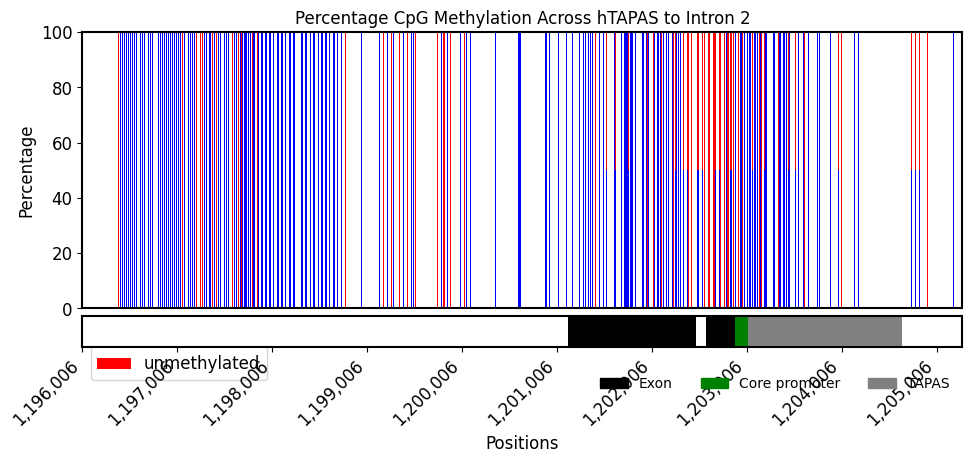

Input: /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed
Methylation sites plotted: 573
Output: /media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPAS_methylation_and_annotation.pdf


In [15]:
TAPASmeth("176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed",
    "PDF/hTAPAS_methylation_and_annotation.pdf",)

Sequence searched: CCGTCCTCCCCTTCACGTCC
Match: 1,197,888-1,197,907 (+ strand)


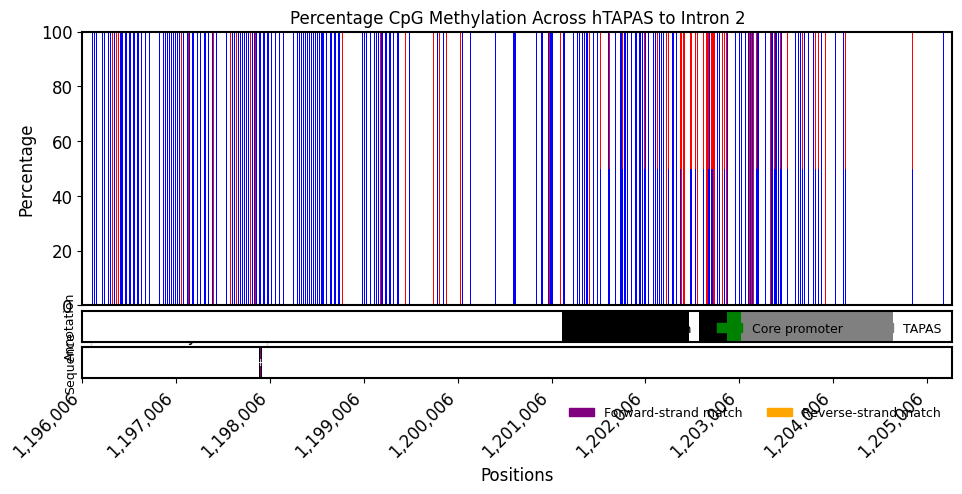

Input: /media/data_01/vapatter/PROJECTS/15-LARS/176_hTERT_target_demeth/T2T/176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed
Output: /media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPAS_methylation_annotation_sequence.pdf


In [17]:
TAPASmeth(
    "176_hTERT_target_demeth/T2T/"
    "176_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_"
    "sup@v4.3.0.bam.sorted.bam.bed",
    "PDF/hTAPAS_methylation_annotation_sequence.pdf",
    binding_sequence="Ccgtcctccccttcacgtcc"
)